In [1]:
import jax
import jax.numpy as jnp
import pickle
from pathlib import Path
from einops import rearrange
import matplotlib.pyplot as plt
from augment import AugmentConfig, augment

In [2]:
file_path = Path.cwd().parent / "cifar-10-python" / "cifar-10-batches-py" / "data_batch_1"

In [3]:
with open(file_path, 'rb') as fo:
    d = pickle.load(fo, encoding='bytes')

In [4]:
img = d[b'data'][0]

In [5]:
img = rearrange(img, "(c h w) -> h w c", h=32, w=32, c=3)

In [6]:
img = img / 255

In [7]:
img = jnp.expand_dims(img, axis=0)

In [8]:
collection = jnp.repeat(img, repeats=15, axis=0)

In [9]:
rng = jax.random.PRNGKey(0)

In [10]:
rng = jax.random.split(rng, num=16)

In [11]:
augment_keys = rng[1:16]

In [12]:
rng = rng[0]

In [19]:
augment_config = AugmentConfig(
    random_crop_resize_crop_size=(24, 24),
    random_crop_resize_new_size=(32, 32, 3),

    random_horizontal_flip_p=0.5,

    brightness_jitter_min_scale=0.5,
    brightness_jitter_max_scale=1.5,

    contrast_jitter_min_scale=0.5,
    contrast_jitter_max_scale=1.5,

    saturation_jitter_min_scale=0.5,
    saturation_jitter_max_scale=1.5,

    random_grayscale_p=0.1,

    normalize_means=(0.4914, 0.4822, 0.4465),
    normalize_stds=(0.2470, 0.2435, 0.2616),
)

In [14]:
augment_map = jax.vmap(augment, in_axes=(0, 0, None))

In [20]:
rngs, augmented_imgs = augment_map(augment_keys, collection, augment_config)

In [21]:
augmented_imgs = jnp.concat([img, augmented_imgs])

In [23]:
def unnormalize(imgs, means, stds):
    means = jnp.asarray(means)[None, None, None, :]
    stds = jnp.asarray(stds)[None, None, None, :]

    imgs = imgs * stds + means
    imgs = jnp.clip(imgs, 0.0, 1.0)

    return imgs


def show_image_grid(imgs,
                    means=(0.4914, 0.4822, 0.4465),
                    stds=(0.2470, 0.2435, 0.2616),
                    save_path="augmentations.png"):
    imgs = unnormalize(imgs, means, stds)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(16):
        axes[i].imshow(imgs[i])
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, transparent=True)
    plt.show()

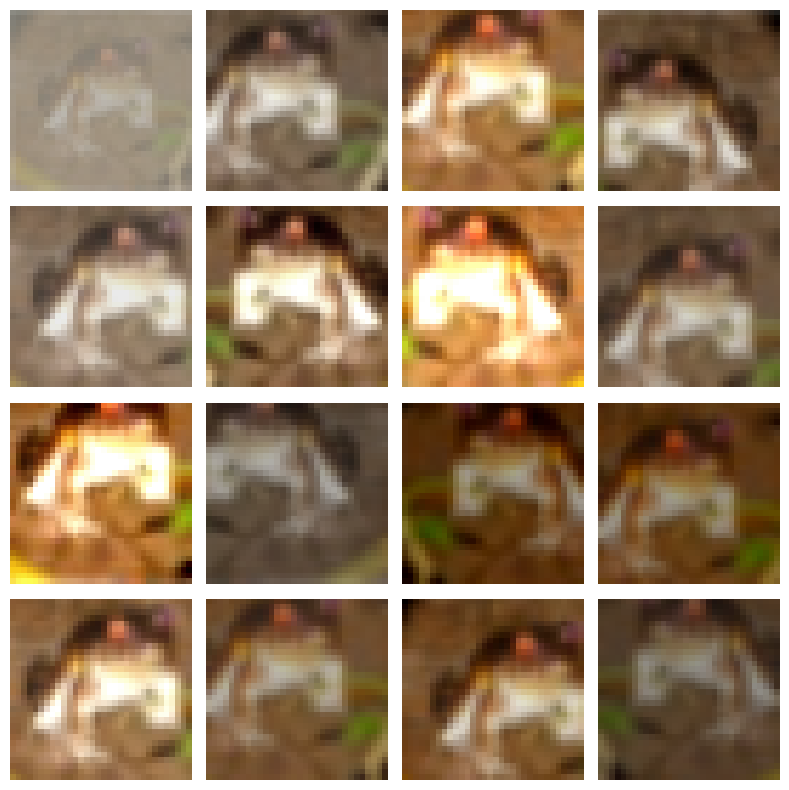

In [24]:
show_image_grid(augmented_imgs)